# PREVISIONE POPOLARITÀ CANZONI

Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## 1. Introduzione e Contesto

### 1.1 Obiettivi del progetto

- **Obiettivo 1** — Predire la popolarità di un brano (regressione sullo score 0–100 e classificazione in classi Low/Medium/High).
- **Obiettivo 2** — Raccomandare brani simili dato un brano in input (content-based recommendation).

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 1.2 Dataset utilizzati
Dataset principale: [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) (su kaggle) — ~114k tracce, 125 generi, 20 colonne, contiene un insieme di brani Spotify, appartenenti a diversi generi musicali, corredati delle rispettive caratteristiche audio.

In [76]:
import os.path
file = "dataset.csv";
if not os.path.exists(file):
    print("Missing dataset");

df = pd.read_csv(file, index_col=0);

df.info(verbose=False, memory_usage="deep");
df.head(1)

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), float64(9), int64(5), object(5)
memory usage: 54.3 MB


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


### 1.3 Descrizione delle variabili
#### Metadati:
- `artists`
- `album_name`
- `track_name`
- `track_genre`
- `duration_ms`
- `explicit`
#### Feature audio (0–1 se non indicato altrimenti):
- `danceability`
- `energy`
- `key (0–11)`
- `loudness (dB)`
- `mode`
- `speechiness`
- `acousticness`
- `instrumentalness`
- `liveness`
- `valence`
- `tempo (BPM)`
- `time_signature (3–7)`
#### Target:
- `popularity (0-100)`

### 1.4 Pulizia iniziale dei dati
Prima di procedere con l’analisi dei dati, si effettua una prima fase di scrematura.

#### Colonne non informative:

`track_id`: identificatore univoco. Non utile al modello, ma lo teniamo fino a fine EDA come chiave di debug.

In [78]:
df.drop(columns=["track_id"], inplace=True)

#### Valori nulli:
Controllo con `.isnull().sum()`. Il dataset ha tipicamente 1–3 righe con nulli su 114k: `dropna()` è sufficiente, l'impatto è trascurabile.

In [80]:
df.isnull().sum()
df = df.dropna()

Rimozione dei brani con `popularity` = 0.

In [82]:
df.info(verbose=False, memory_usage="deep")
df = df[df['popularity'] != 0]
df.info(verbose=False, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Columns: 19 entries, artists to track_genre
dtypes: bool(1), float64(9), int64(5), object(4)
memory usage: 45.7 MB
<class 'pandas.core.frame.DataFrame'>
Index: 97980 entries, 0 to 113999
Columns: 19 entries, artists to track_genre
dtypes: bool(1), float64(9), int64(5), object(4)
memory usage: 39.2 MB


Una frazione consistente del dataset (~7%) ha `popularity` = 0.

Questo insieme è formato da:
- brani senza ascolti
- brani recenti
- artefatti

Il target per queste righe è di fatto mancante. Se non rimosse rischiano di distorce la regressione.

#### Duplicati
Il dataset contiene molte righe con stesso `track_name` + `artists` (stesso brano in più album). 
Questo è un problema per due motivi:

- inquinano il test set: lo stesso brano in train e test → leakage classico;
- distorcono l'EDA: generi con molte compilation (acoustic, christmas) risultano sovrarappresentati.

Aggregaione dei brani con stesso nome e artisti, mantenendo solo la versione con popularity massima.

In [84]:
df.info(verbose=False, memory_usage="deep")
df = df.sort_values('popularity', ascending=False).drop_duplicates(subset=['track_name', 'artists'])
df.info(verbose=False, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 97980 entries, 0 to 113999
Columns: 19 entries, artists to track_genre
dtypes: bool(1), float64(9), int64(5), object(4)
memory usage: 39.2 MB
<class 'pandas.core.frame.DataFrame'>
Index: 76585 entries, 81051 to 16695
Columns: 19 entries, artists to track_genre
dtypes: bool(1), float64(9), int64(5), object(4)
memory usage: 31.1 MB


### Conversioni e derivazioni
Conversione dei millisecondi in secondi.

In [85]:
df['duration_s'] = df['duration_ms'] / 1000
df = df.drop(columns=['duration_ms'])

Creazione della colonna `num_artists` (numero di artisti per ogni brano).

In [87]:
df['num_artists'] = df['artists'].astype(str).str.split(';').str.len()
df.head(1)

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s,num_artists
81051,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,False,0.714,0.472,2,-7.375,1,0.0864,0.013,0.000005,0.266,0.238,131.121,4,pop,156.943,2


Con questa prima scrematura, la dimensione del dataset è stata ridotta ulteriormente.

In [89]:
df.info(verbose=False, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 76585 entries, 81051 to 16695
Columns: 20 entries, artists to num_artists
dtypes: bool(1), float64(10), int64(5), object(4)
memory usage: 31.7 MB


## Analisi dei dati

In [91]:
print('tracks: \t' + str(len(df)))
print('artists:\t' + str(df['artists'].nunique()))
print('albums: \t' + str(df.groupby(['album_name', 'artists'], observed=True).ngroups))
print('genres: \t' + str(df['track_genre'].nunique()))

tracks: 	76585
artists:	29826
albums: 	53199
genres: 	114


In [92]:
def plot_bar(feature, n=None, title=None, bins=None, labels=None):
    col = df[feature]
    
    if bins is not None:
        col = pd.cut(col, bins=bins, labels=labels, include_lowest=True)
        values = col.value_counts()
        if labels is not None:
            values = values.reindex(labels)  # mantiene l'ordine low -> medium -> high
    else:
        values = col.value_counts()
    
    if n is not None:
        values = values.head(n)
    
    colors = [f"#{np.random.randint(0, 0xFFFFFF):06x}" for _ in range(len(values))]
    ax = values.plot.bar(figsize=(15, 4), color=colors)
    ax.set_title(title)
    plt.xticks(rotation=0)
    plt.show()

Di seguito vengono visualizzati alcuni istogrammi e statistiche per analizzare la distribuzione dei dati.

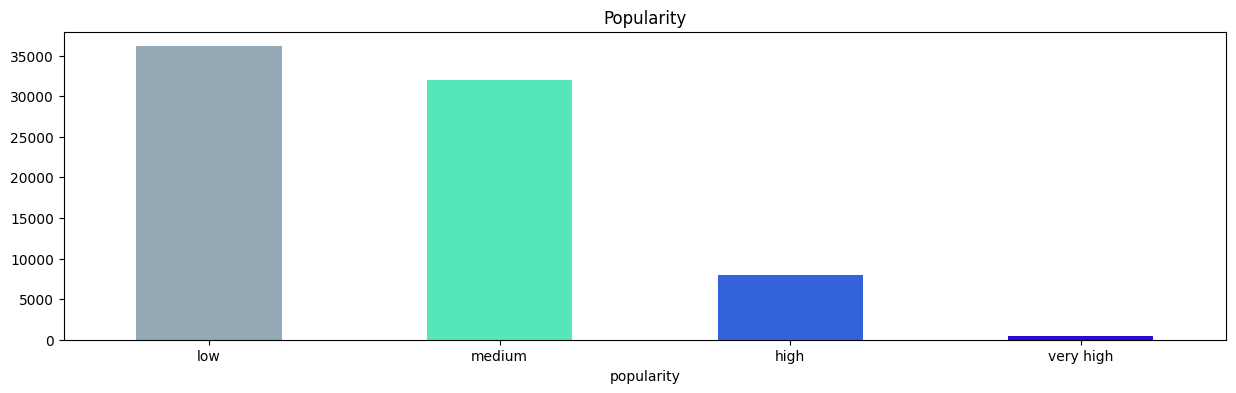

count    76585.000000
mean        37.439303
std         17.837212
min          1.000000
25%         23.000000
50%         37.000000
75%         50.000000
max        100.000000
Name: popularity, dtype: float64

In [94]:
plot_bar('popularity',
         bins=[0, 35, 60, 80, 100],
         labels=['low', 'medium', 'high', 'very high'],
         title='Popularity')
df["popularity"].describe()

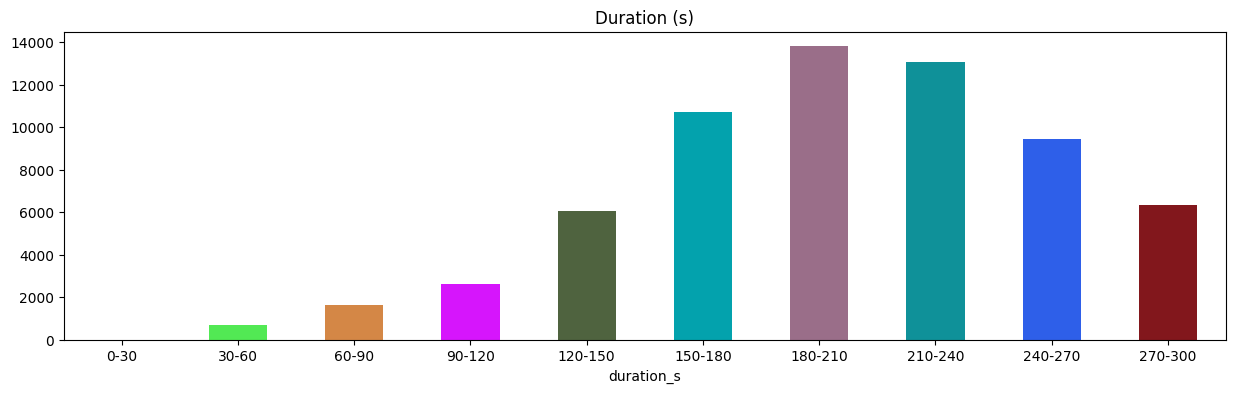

count    76585.000000
mean       231.499933
std        116.630143
min         24.266000
25%        173.973000
50%        215.693000
75%        267.847000
max       5237.295000
Name: duration_s, dtype: float64

In [95]:
plot_bar('duration_s',
         bins=[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300],
         labels=['0-30', '30-60', '60-90', '90-120', '120-150', '150-180', '180-210', '210-240', '240-270', '270-300'],
         title='Duration (s)')
df["duration_s"].describe()

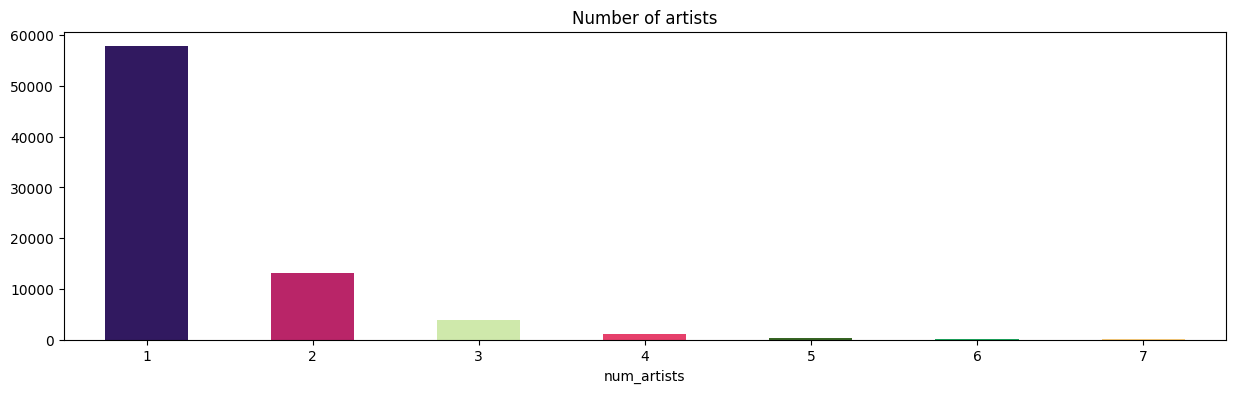

count    76585.000000
mean         1.368036
std          0.881734
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         38.000000
Name: num_artists, dtype: float64

In [96]:
plot_bar("num_artists", 7, "Number of artists")
df["num_artists"].describe()

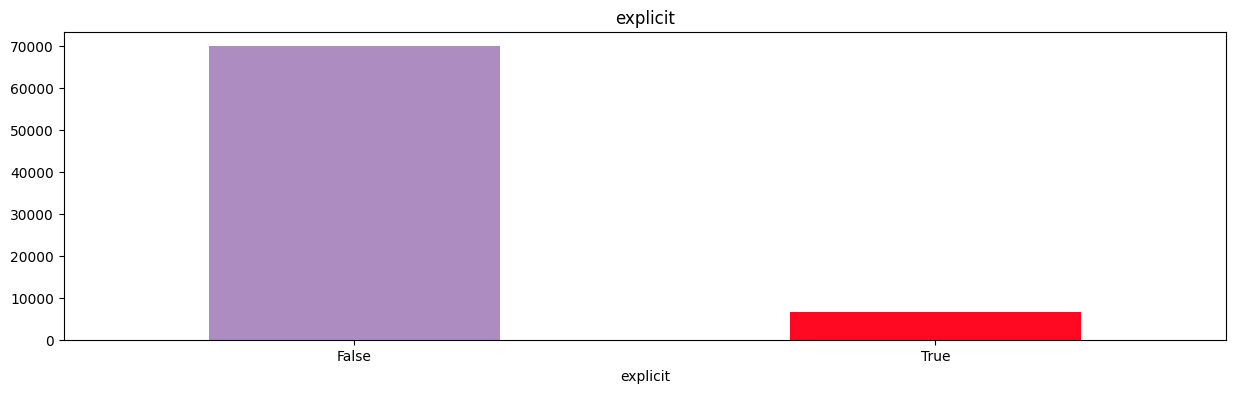

In [97]:
plot_bar("explicit", 2, "explicit")

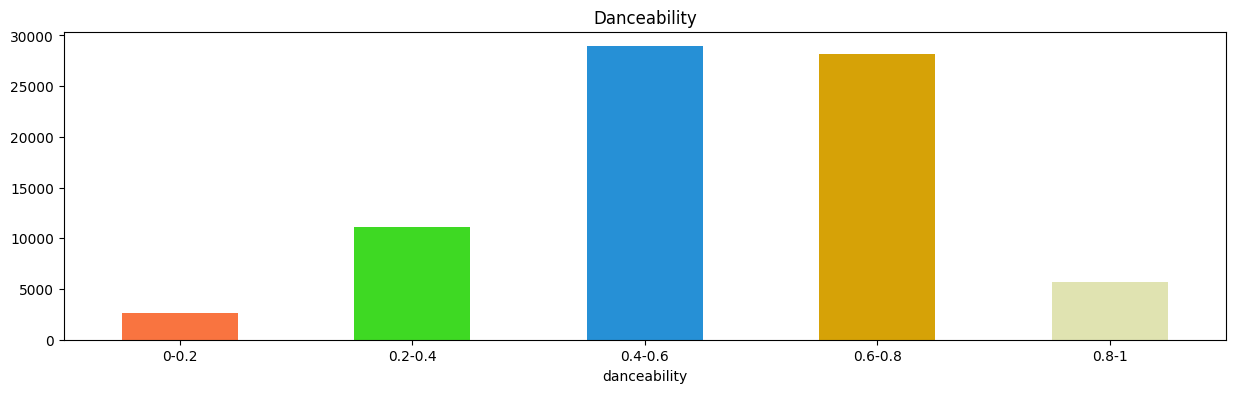

count    76585.000000
mean         0.561699
std          0.176139
min          0.000000
25%          0.450000
50%          0.575000
75%          0.691000
max          0.985000
Name: danceability, dtype: float64

In [99]:

plot_bar('danceability',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Danceability')
df["danceability"].describe()

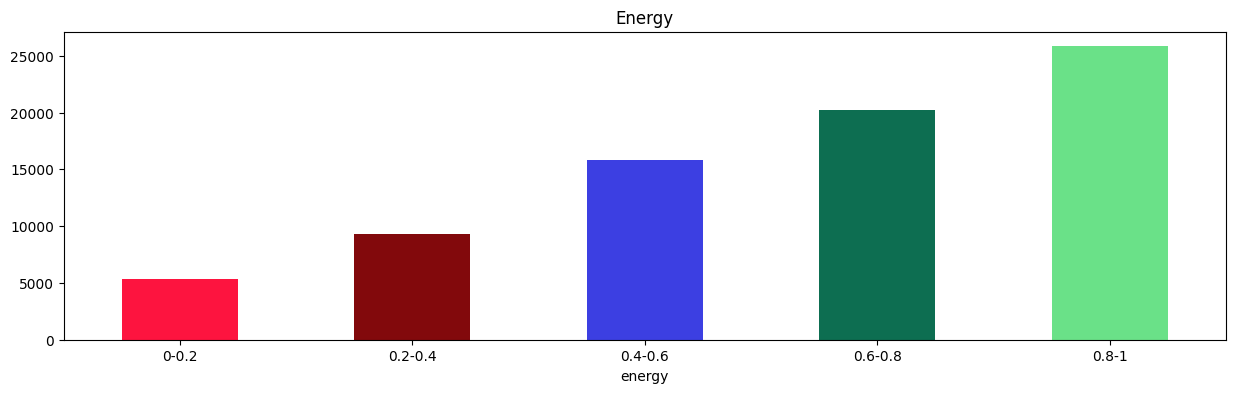

count    76585.000000
mean         0.640237
std          0.255275
min          0.000000
25%          0.464000
50%          0.682000
75%          0.859000
max          1.000000
Name: energy, dtype: float64

In [101]:

plot_bar('energy',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Energy')
df["energy"].describe()

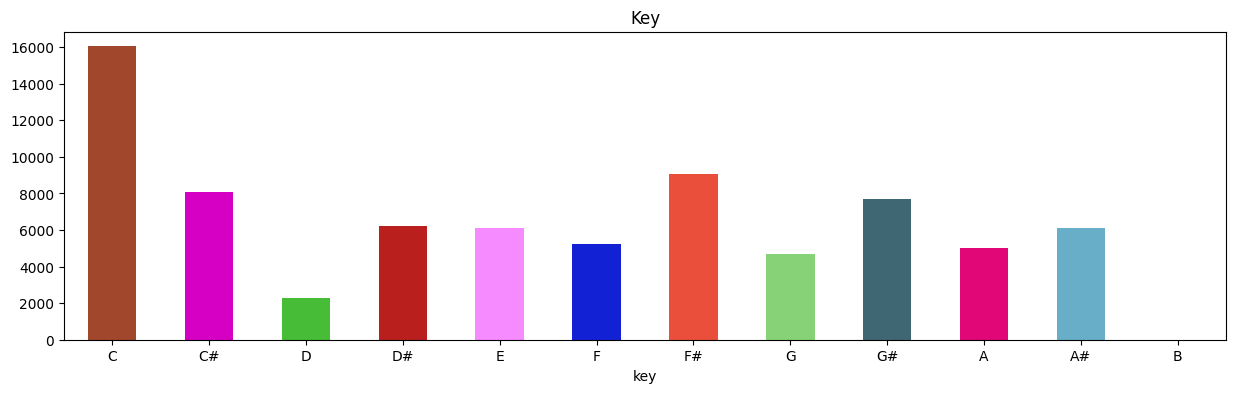

In [102]:
plot_bar('key',
         bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
         labels=['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'],
         title='Key')

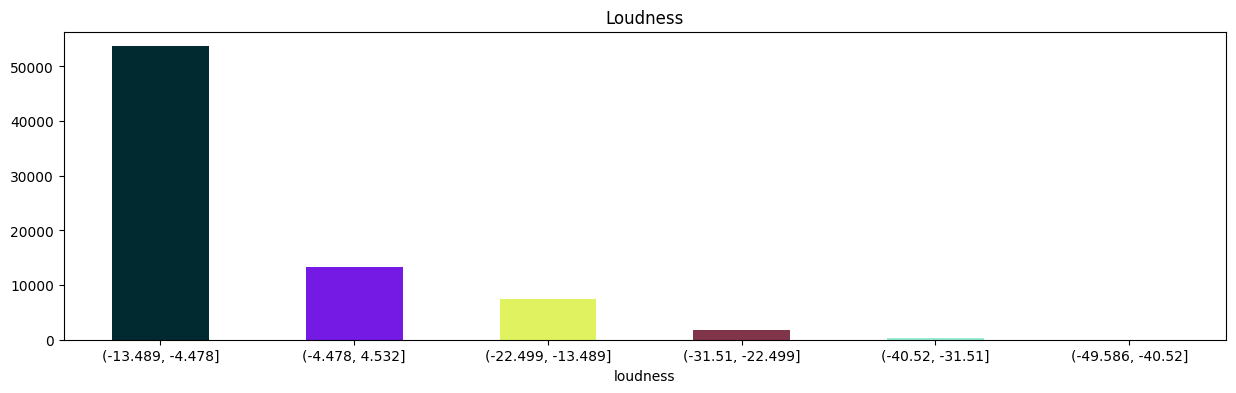

count    76585.000000
mean        -8.496817
std          5.187767
min        -49.531000
25%        -10.327000
50%         -7.231000
75%         -5.130000
max          4.532000
Name: loudness, dtype: float64

In [111]:
plot_bar('loudness',
         bins=6,
         title='Loudness')
df["loudness"].describe()

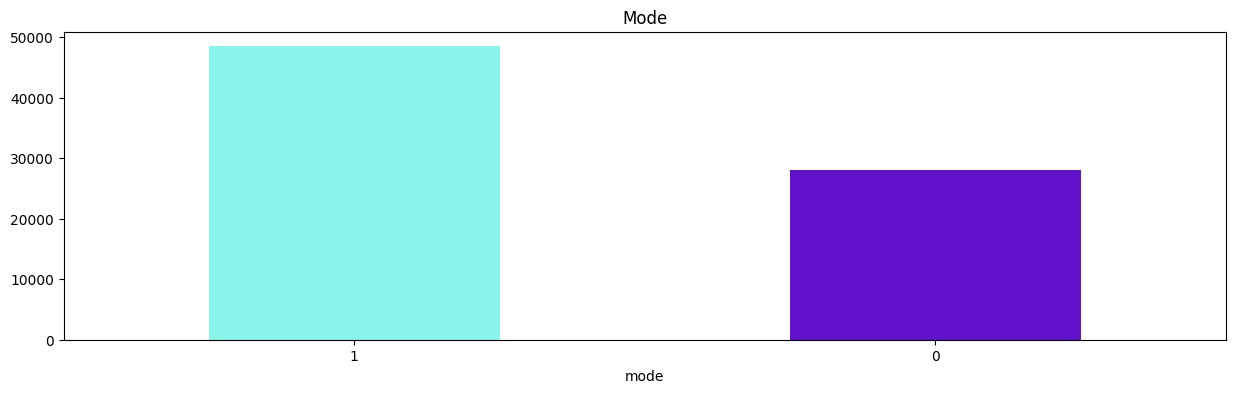

In [113]:

plot_bar("mode", 2, "Mode")

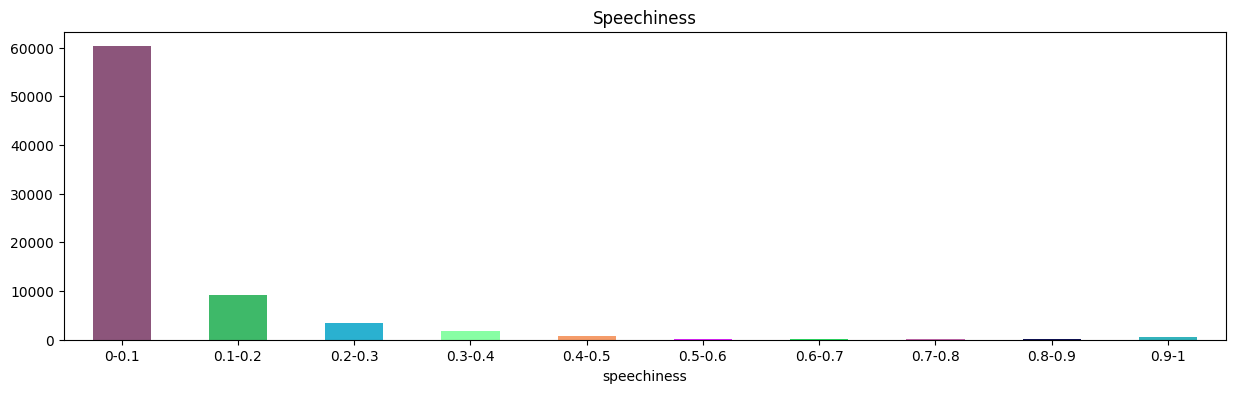

count    76585.000000
mean         0.089657
std          0.118416
min          0.000000
25%          0.036000
50%          0.049200
75%          0.087600
max          0.965000
Name: speechiness, dtype: float64

In [115]:

plot_bar('speechiness',
         bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
         labels=['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1'],
         title='Speechiness')
df["speechiness"].describe()

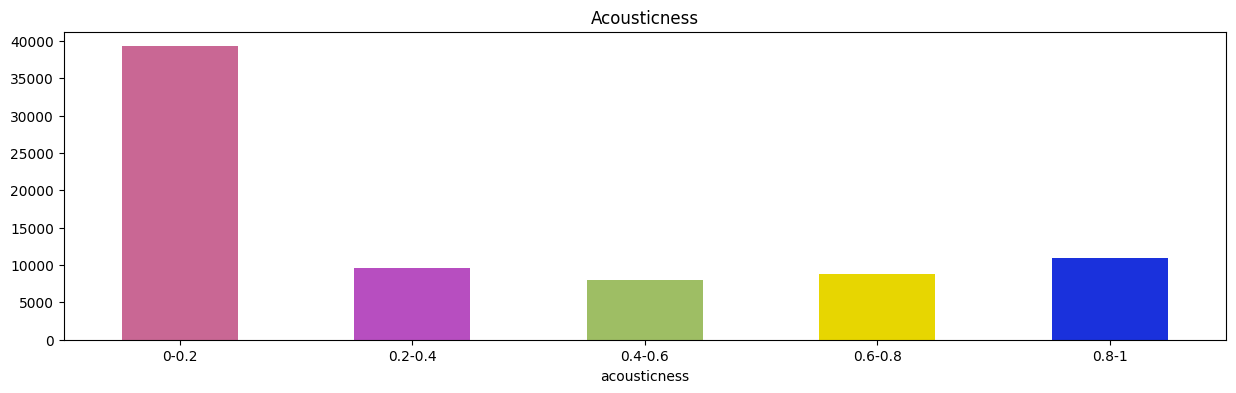

count    76585.000000
mean         0.322789
std          0.335326
min          0.000000
25%          0.015000
50%          0.184000
75%          0.614000
max          0.996000
Name: acousticness, dtype: float64

In [117]:
plot_bar('acousticness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Acousticness')
df["acousticness"].describe()

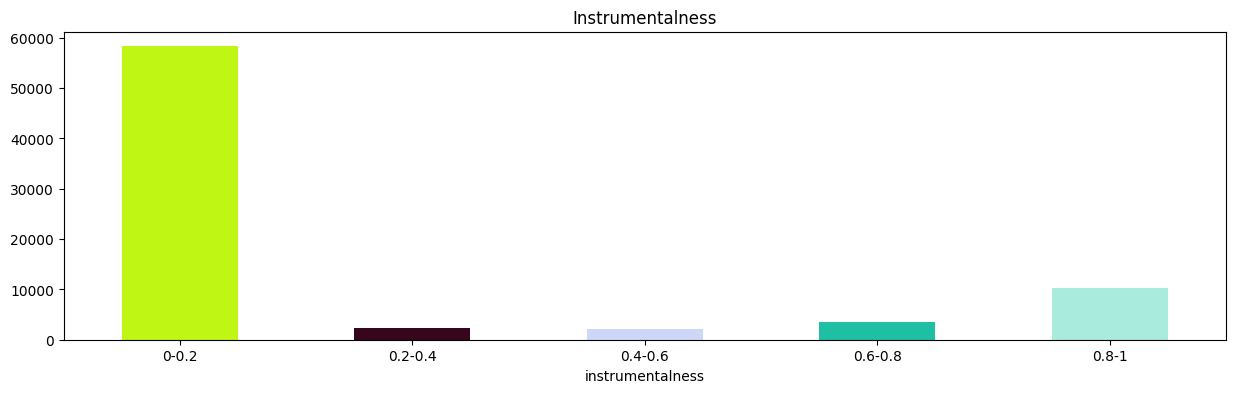

count    76585.000000
mean         0.183119
std          0.330332
min          0.000000
25%          0.000000
50%          0.000085
75%          0.144000
max          1.000000
Name: instrumentalness, dtype: float64

In [119]:
plot_bar('instrumentalness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Instrumentalness')
df["instrumentalness"].describe()

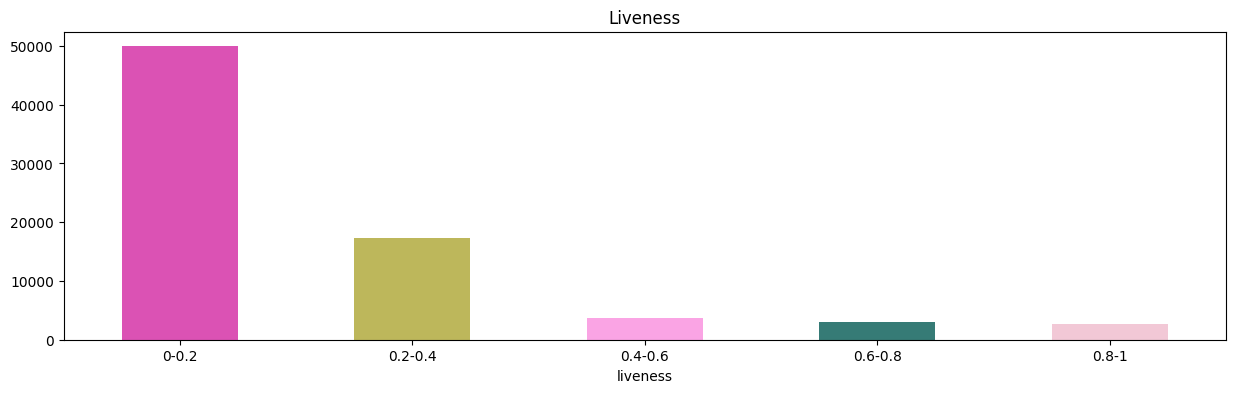

count    76585.000000
mean         0.221382
std          0.200123
min          0.000000
25%          0.098700
50%          0.133000
75%          0.285000
max          1.000000
Name: liveness, dtype: float64

In [121]:
plot_bar('liveness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Liveness')
df["liveness"].describe()

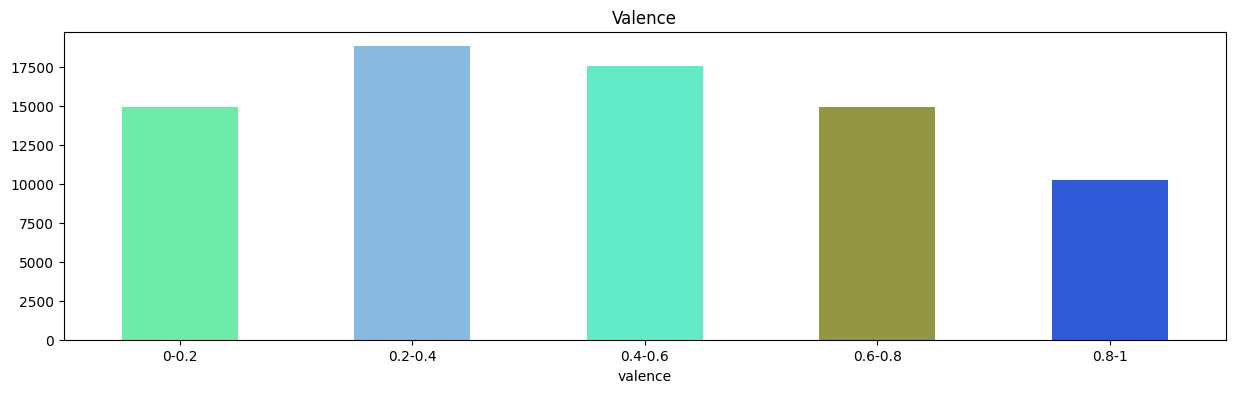

count    76585.000000
mean         0.465633
std          0.262394
min          0.000000
25%          0.246000
50%          0.451000
75%          0.677000
max          0.995000
Name: valence, dtype: float64

In [126]:
plot_bar('valence',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Valence')
df["valence"].describe()

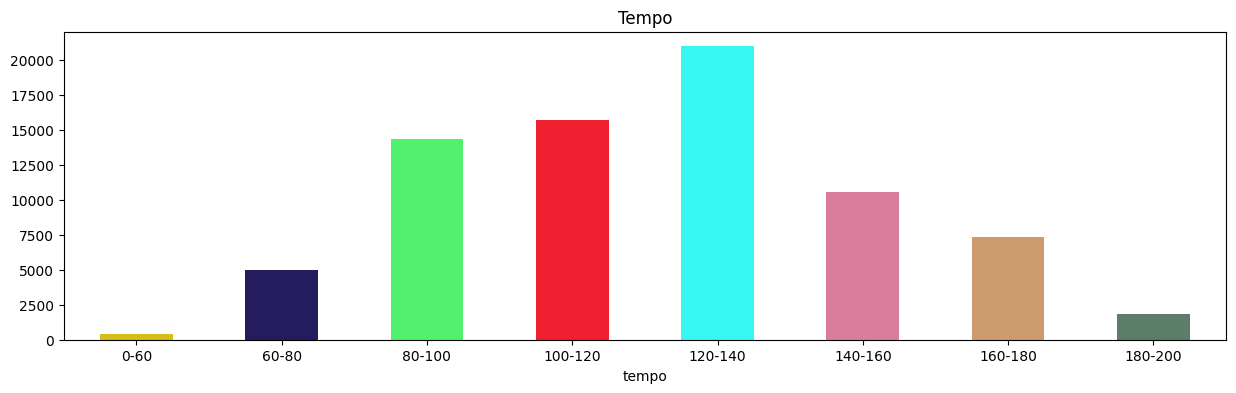

count    76585.000000
mean       122.417377
std         30.076935
min          0.000000
25%         99.915000
50%        122.369000
75%        140.660000
max        243.372000
Name: tempo, dtype: float64

In [128]:
plot_bar('tempo',
         bins=[0, 60, 80, 100, 120, 140, 160, 180, 200],
         labels=['0-60', '60-80', '80-100', '100-120', '120-140', '140-160', '160-180', '180-200'],
         title='Tempo')
df["tempo"].describe()

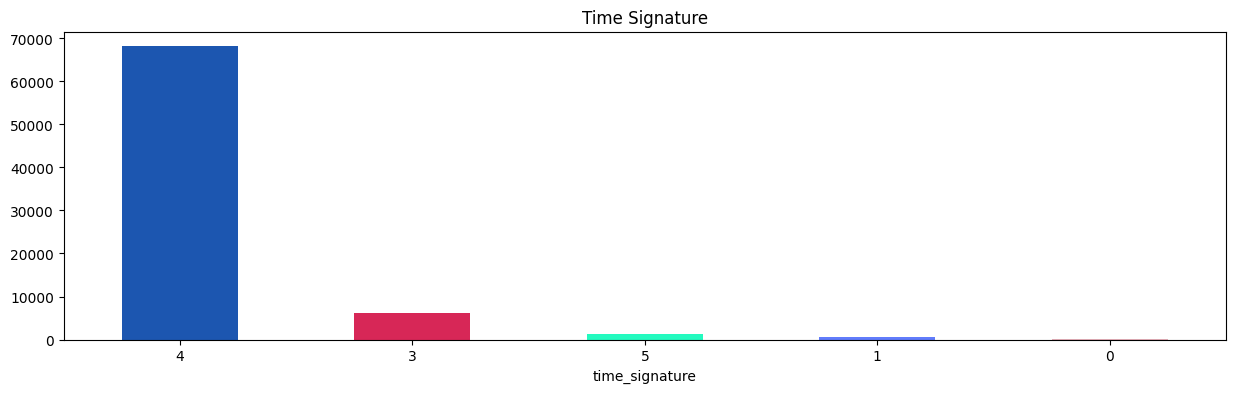

In [134]:
plot_bar("time_signature", 5, "Time Signature")

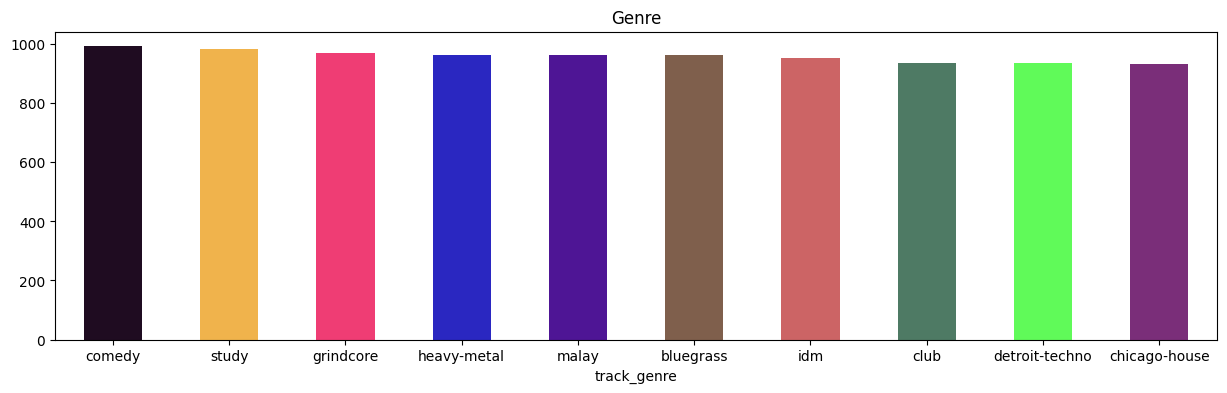

In [136]:
plot_bar("track_genre", 10, "Genre")

## Preparazione dei dati

Creazione di una copia del dataset, rimozione delle feature inutilizzate.

In [138]:
df_model = df.copy()
df_model = df_model.drop(columns=['artists', 'album_name', 'track_name'])

Rimozione dei brani con caratteristiche anomale.

In [140]:
df_model = df_model[(df_model['duration_s'] >= 30) & (df_model['duration_s'] <= 1800)]
df_model = df_model[(df_model['loudness'] >= -60) & (df_model['loudness'] <= 0)]
df_model = df_model[(df_model['tempo'] >= 30) & (df_model['tempo'] <= 300)]

Conversione da bool a int

In [144]:
df_model['explicit'] = df_model['explicit'].astype(int)

Conversione delle feature categoriche in valori numerici

In [146]:
df_model = pd.get_dummies(df_model, columns=['track_genre'], drop_first=True)

In [148]:
df_model.info(verbose=False, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 76355 entries, 81051 to 16695
Columns: 129 entries, popularity to track_genre_world-music
dtypes: bool(113), float64(10), int64(6)
memory usage: 18.1 MB


## Preparazione del modello

Separazione dei risultati da prevedere e creazione train e test set.

In [150]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (50903, 128)
Test set:     (25452, 128)


### Regressione lineare

In [152]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear.fit(X_train, y_train)

preds = linear.predict(X_test)
print(f"MSE:  {mean_squared_error(y_test, preds):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.3f}")
print(f"MAE:  {np.mean(np.abs(y_test - preds)):.3f}")
print(f"R²:   {r2_score(y_test, preds):.3f}")

MSE:  161.743
RMSE: 12.718
MAE:  9.251
R²:   0.486


### Regressione Lasso

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid = {'lasso__alpha': [0.01, 0.1, 0.5, 1, 5]}
gs_lasso = GridSearchCV(lasso, grid, cv=5, scoring='r2')
gs_lasso.fit(X_train, y_train)

preds = gs_lasso.predict(X_test)
print(f"Best alpha: {gs_lasso.best_params_}")
print(f"MSE:  {mean_squared_error(y_test, preds):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.3f}")
print(f"MAE:  {np.mean(np.abs(y_test - preds)):.3f}")
print(f"R²:   {r2_score(y_test, preds):.3f}")

### Regressione Ridge

In [37]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [0.1, 1, 10, 50, 100]}
gs_ridge = GridSearchCV(ridge, grid, cv=5, scoring='r2')
gs_ridge.fit(X_train, y_train)

preds = gs_ridge.predict(X_test)
print(f"Best alpha: {gs_ridge.best_params_}")
print(f"MSE:  {mean_squared_error(y_test, preds):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.3f}")
print(f"MAE:  {np.mean(np.abs(y_test - preds)):.3f}")
print(f"R²:   {r2_score(y_test, preds):.3f}")

Best alpha: {'ridge__alpha': 10}
MSE:  161.742
RMSE: 12.718
MAE:  9.251
R²:   0.486


è normale che siano tutti uguali? Sì, è normalissimo e anzi è un risultato narrativamente perfetto per il tuo progetto\.
Tutti e tre i modelli lineari convergono sullo stesso R² intorno a 0\.48:
Linear Regression  →  R² = 0\.481
Lasso              →  R² = 0\.483  
Ridge              →  R² = 0\.486
Questo ti dice una cosa precisa: il limite non è la regolarizzazione, ma la linearità del modello\. Hai estratto tutto il segnale lineare che c'era nei dati, e la regolarizzazione non cambia nulla perché il problema non è l'overfitting ma il fatto che la relazione tra feature audio e popolarità non è lineare\.

# Conclusioni

In conclusione, il progetto ha permesso di sviluppare un modello in grado di stimare la popolarità dei brani Spotify a partire dalle loro caratteristiche. I risultati ottenuti mostrano come alcune variabili risultino più rilevanti di altre nel determinare il successo di un brano, evidenziando l’importanza dell’analisi dei dati nel comprendere fenomeni complessi.

Pur fornendo prestazioni soddisfacenti, il modello presenta margini di miglioramento, legati sia alla qualità dei dati sia alla possibile integrazione di ulteriori variabili. In prospettiva, l’affinamento delle tecniche di modellazione e l’ampliamento del dataset potrebbero contribuire a ottenere previsioni ancora più accurate.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fe8ba0a0-c743-4de6-b168-793b01eb47d6' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>